# PlasAnn annotation investigation — what is *on* the plasmids

**Annotation:** PlasAnn v1.1.6 run on the 208,248-plasmid working set; **208,177 annotated (99.97%)**.
Each plasmid's genes are predicted with Prodigal and functionally annotated by BLAST against the PlasAnn
curated database, plus origins of replication/transfer, transposons & mobile elements, replicons, and
Infernal/Rfam ncRNAs.

**What this notebook does.** Investigates the *gene content* of the working set — the functional
category mix, the most common genes, replicon content, and how functional content varies across the
locked habitat taxonomy. Companion to `notebooks/plasmid_data_investigation.ipynb` (which covers
provenance / physical / environment / geography).

**Data source.** Reads `data/plasmidscope_primary/plasmid_metadata_master.tsv` (the `plasann_*` columns)
and the frequency tables from `scripts/aggregate_plasann_genes.py`
(`plasann_category_totals.tsv`, `plasann_feature_types.tsv`, `plasann_gene_freq.tsv`,
`plasann_replicon_family_freq.tsv`). Built by `scripts/build_plasann_notebook.py`.

**Caveats.** (1) `ORF` = a predicted CDS with **no** functional BLAST hit (hypothetical). (2) PlasAnn's
**replicon** calls use a permissive 60% identity BLAST vs the PlasmidFinder database — treat them as an
annotation signal, not authoritative Inc typing (a standard-threshold MOB-suite/PlasmidFinder pass is
the authoritative layer). (3) 71 plasmids are unannotated: 3 have no FASTA, 68 are tiny feature-less
micro-plasmids. (4) The simulated-community + lab artifacts (64,745) are excluded from the habitat
cross-cuts, as elsewhere.

## 0 · Setup

In [1]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

while not Path("data/plasmidscope_primary/plasmid_metadata_master.tsv").exists() and Path.cwd() != Path.cwd().parent:
    os.chdir("..")
pd.set_option("display.width", 150); pd.set_option("display.max_columns", 60)

FIG = Path("reports/figures/plasann"); FIG.mkdir(parents=True, exist_ok=True)
PP = "data/plasmidscope_primary"

PAL = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
INK, MUTED, GRID = "#1a1a1a", "#6b7280", "#e6e8eb"
GREY, LGREY = "#9aa0a6", "#c9ccd1"
mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "figure.facecolor": "white", "axes.facecolor": "white",
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold", "axes.labelsize": 11,
    "axes.labelcolor": INK, "text.color": INK, "axes.edgecolor": "#c9ccd1", "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False,
})
HAB_COLORS = {"Host-associated": "#2a78d6", "Environmental": "#1baf7a", "Engineered": "#eb6834",
              "Unknown": GREY}
# functional-category palette (fixed); categories not listed -> grey
CAT_COLORS = {
    "Conjugation": "#2a78d6", "Non-conjugative DNA mobility": "#eb6834", "Mobile Element": "#eda100",
    "Plasmid Maintenance, Replication and Regulation": "#4a3aa7", "Antibiotic Resistance": "#e34948",
    "Metal and Biocide Resistance": "#e87ba4", "Virulence and Defense Mechanism": "#008300",
    "Metabolism": "#1baf7a", "Toxin-Antitoxin System": "#8a5a2b", "Stress Response": "#5aa9c9",
    "Non coding RNA/Regulatory elements": "#b07aa1", "Origin of Replication": "#7a6a3a",
    "Origin of Transfer": "#c98a3a", "Replicon": "#3a6ea5",
}


def catcol(c):
    return CAT_COLORS.get(c, GREY)


def save(fig, name):
    fig.savefig(FIG / f"{name}.png", dpi=150, bbox_inches="tight", facecolor="white")


def hbar_labels(ax, values, fmt="{:,.0f}", dx=None):
    vals = list(values); xmax = max(vals) if vals else 1
    dx = dx if dx is not None else xmax * 0.01
    for i, v in enumerate(vals):
        ax.text(v + dx, i, fmt.format(v), va="center", ha="left", fontsize=9, color=INK)
    ax.set_xlim(0, xmax * 1.13)

In [2]:
M = pd.read_csv(f"{PP}/plasmid_metadata_master.tsv", sep="\t", dtype=str, keep_default_na=False)
PA_NUM = [c for c in M.columns if c.startswith("plasann_n") or c in ("plasann_has_oriv", "plasann_has_orit")]
for c in PA_NUM + ["size_bp"]:
    M[c] = pd.to_numeric(M[c], errors="coerce")
M["plasann_annotated"] = pd.to_numeric(M["plasann_annotated"], errors="coerce").fillna(0).astype(int)
A = M[M.plasann_annotated == 1].copy()            # annotated plasmids
R = A[~A.hab_top.isin(["Simulated-artifact", "Lab-artifact"])].copy()   # + real-habitat subset

cat = pd.read_csv(f"{PP}/plasann_category_totals.tsv", sep="\t")
ft = pd.read_csv(f"{PP}/plasann_feature_types.tsv", sep="\t")
genes = pd.read_csv(f"{PP}/plasann_gene_freq.tsv", sep="\t")
repfam = pd.read_csv(f"{PP}/plasann_replicon_family_freq.tsv", sep="\t")
print(f"annotated plasmids: {len(A):,}  |  real-habitat annotated: {len(R):,}")
print(f"categories: {len(cat)}  genes(>=5): {len(genes):,}  replicon families: {len(repfam):,}")

annotated plasmids: 208,177  |  real-habitat annotated: 143,432
categories: 17  genes(>=5): 10,437  replicon families: 205


### Dataset at a glance

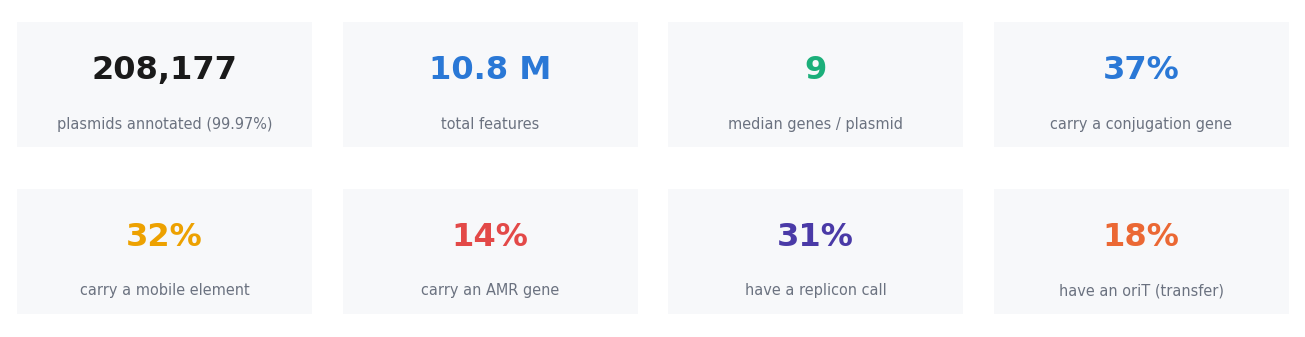

In [3]:
def stat_tiles(items, ncol=4, figsize=(12, 3.2)):
    nrow = int(np.ceil(len(items) / ncol)); fig, axes = plt.subplots(nrow, ncol, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()
    for ax, (big, lab, col) in zip(axes, items):
        ax.axis("off")
        ax.add_patch(plt.Rectangle((0.02, 0.08), 0.96, 0.84, transform=ax.transAxes, facecolor="#f7f8fa", edgecolor="none"))
        ax.text(0.5, 0.60, big, transform=ax.transAxes, ha="center", va="center", fontsize=21, fontweight="bold", color=col)
        ax.text(0.5, 0.24, lab, transform=ax.transAxes, ha="center", va="center", fontsize=9.5, color=MUTED)
    for ax in axes[len(items):]:
        ax.axis("off")
    fig.tight_layout(); return fig

n = len(A)
def pct(col):
    return f"{(A[col] > 0).mean()*100:.0f}%"
tiles = [
    (f"{n:,}", "plasmids annotated (99.97%)", INK),
    (f"{int(ft.occurrences.sum())/1e6:.1f} M", "total features", PAL[0]),
    (f"{int(A.plasann_n_cds.median())}", "median genes / plasmid", PAL[1]),
    (f"{pct('plasann_n_conjugation')}", "carry a conjugation gene", PAL[0]),
    (f"{pct('plasann_n_mobile_element')}", "carry a mobile element", PAL[2]),
    (f"{pct('plasann_n_amr')}", "carry an AMR gene", PAL[5]),
    (f"{pct('plasann_n_replicons')}", "have a replicon call", PAL[4]),
    (f"{(A.plasann_has_orit > 0).mean()*100:.0f}%", "have an oriT (transfer)", PAL[7]),
]
fig = stat_tiles(tiles); save(fig, "00_glance"); plt.show()

## 1 · Annotation overview

What kinds of features were called, and how many per plasmid. `CDS` dominates (protein-coding genes);
the rest are mobile elements (MGE), ncRNAs, replicons and origins.

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.


findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.


...

findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['DejaVu Sans Display'] not found. Falling back to DejaVu Sans.


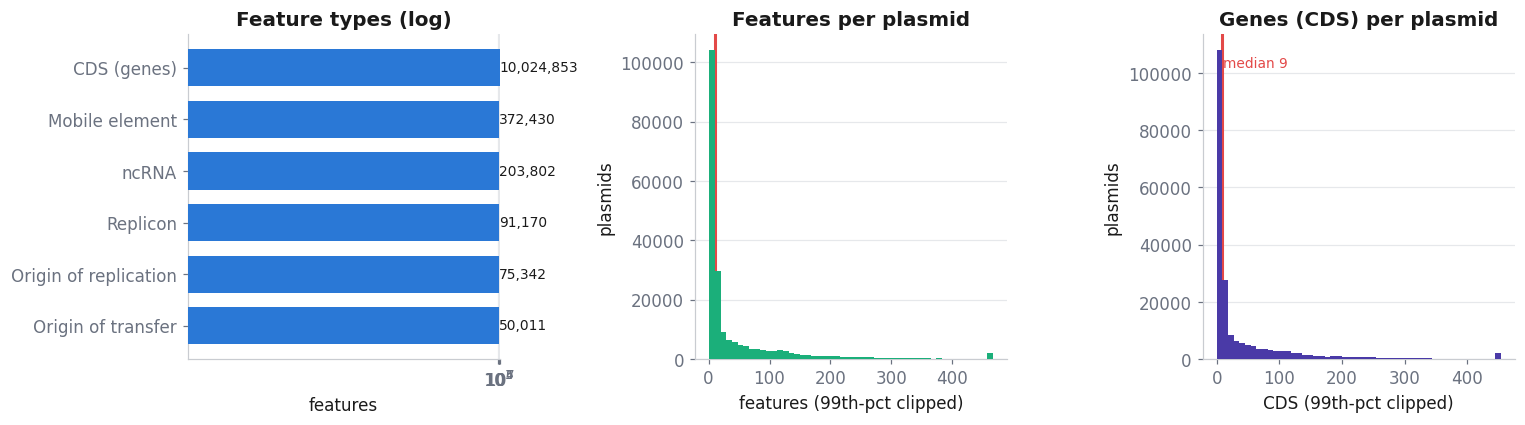

In [4]:
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(14, 4))

FTN = {"CDS": "CDS (genes)", "MGE": "Mobile element", "NC_RNA": "ncRNA", "Replicon": "Replicon",
       "ORIV": "Origin of replication", "ORIT": "Origin of transfer"}
f = ft.copy(); f["lab"] = f.feature_type.map(lambda x: FTN.get(x, x))
f = f.sort_values("occurrences")
a1.barh(f.lab, f.occurrences, color=PAL[0], height=0.72, zorder=3)
hbar_labels(a1, f.occurrences.values, fmt="{:,.0f}")
a1.set_xscale("log"); a1.set_title("Feature types (log)"); a1.set_xlabel("features"); a1.grid(axis="y", visible=False)

nf = A.plasann_n_features.clip(upper=A.plasann_n_features.quantile(0.99))
a2.hist(nf, bins=50, color=PAL[1], zorder=3)
a2.axvline(A.plasann_n_features.median(), color=PAL[5], lw=2)
a2.set_title("Features per plasmid"); a2.set_xlabel("features (99th-pct clipped)"); a2.set_ylabel("plasmids")
a2.grid(axis="x", visible=False)

nc = A.plasann_n_cds.clip(upper=A.plasann_n_cds.quantile(0.99))
a3.hist(nc, bins=50, color=PAL[4], zorder=3)
a3.axvline(A.plasann_n_cds.median(), color=PAL[5], lw=2)
a3.text(A.plasann_n_cds.median()+1, a3.get_ylim()[1]*0.9, f"median {int(A.plasann_n_cds.median())}", color=PAL[5], fontsize=9)
a3.set_title("Genes (CDS) per plasmid"); a3.set_xlabel("CDS (99th-pct clipped)"); a3.set_ylabel("plasmids")
a3.grid(axis="x", visible=False)
fig.tight_layout(); save(fig, "01_feature_overview"); plt.show()

## 2 · Functional categories — the *type of genes*

PlasAnn assigns each gene a functional category. Below, how many plasmids carry each category (reach)
and how many gene copies exist in total (abundance). `ORF` (hypothetical, no functional hit) and `Other`
are shown greyed for context but are not functional classes.

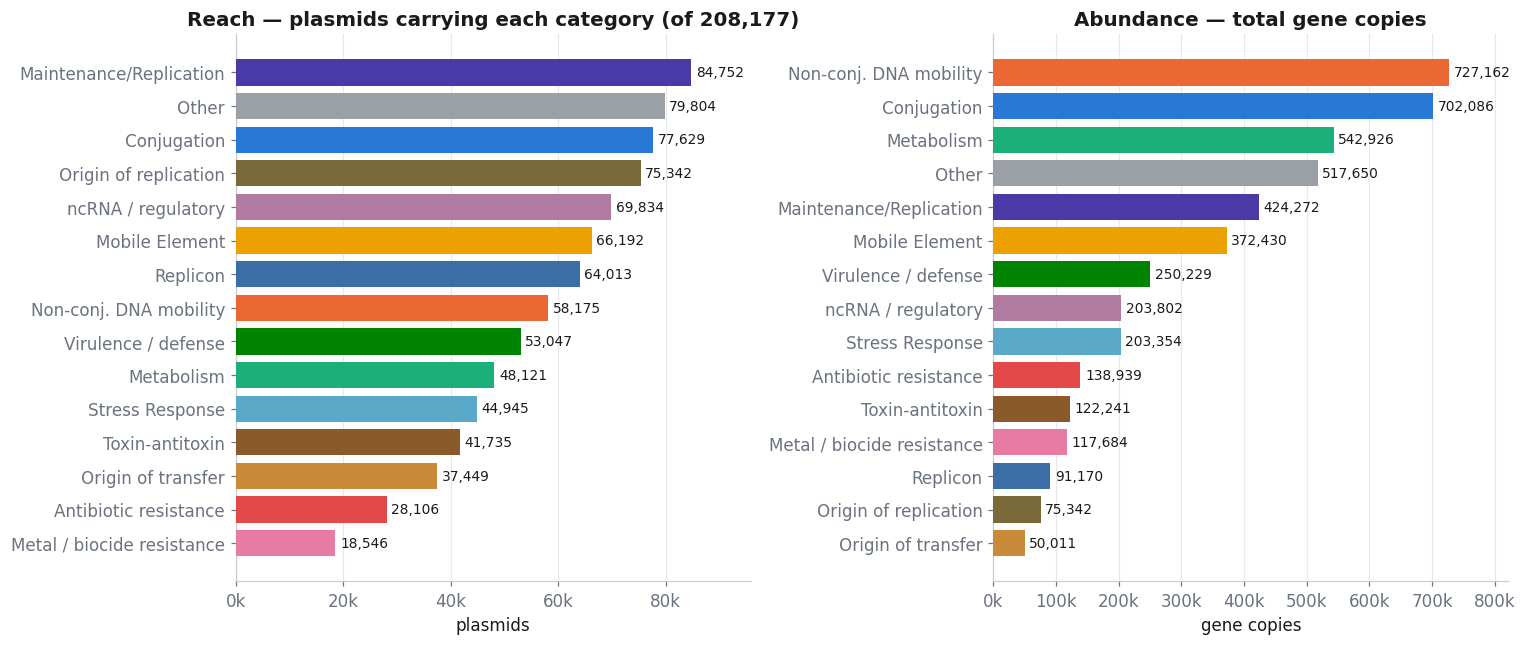

In [5]:
DROP = {"Open reading frame"}
CANON = {"PLasmid Maintenance, Replication and Regulation": "Plasmid Maintenance, Replication and Regulation"}
c = cat.copy()
c["category"] = c.category.replace(CANON)
c = c.groupby("category", as_index=False).sum().sort_values("n_plasmids")
c = c[~c.category.isin(DROP)]

SHORT = {"Plasmid Maintenance, Replication and Regulation": "Maintenance/Replication",
         "Non-conjugative DNA mobility": "Non-conj. DNA mobility",
         "Non coding RNA/Regulatory elements": "ncRNA / regulatory",
         "Virulence and Defense Mechanism": "Virulence / defense",
         "Metal and Biocide Resistance": "Metal / biocide resistance",
         "Antibiotic Resistance": "Antibiotic resistance", "Toxin-Antitoxin System": "Toxin-antitoxin",
         "Origin of Replication": "Origin of replication", "Origin of Transfer": "Origin of transfer"}
c["lab"] = c.category.map(lambda x: SHORT.get(x, x))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 6))
cols = [catcol(x) for x in c.category]
a1.barh(c.lab, c.n_plasmids, color=cols, height=0.78, zorder=3)
hbar_labels(a1, c.n_plasmids.values)
a1.set_title(f"Reach — plasmids carrying each category (of {len(A):,})"); a1.set_xlabel("plasmids")
a1.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k")); a1.grid(axis="y", visible=False)

c2 = c.sort_values("occurrences")
a2.barh(c2.lab, c2.occurrences, color=[catcol(x) for x in c2.category], height=0.78, zorder=3)
hbar_labels(a2, c2.occurrences.values)
a2.set_title("Abundance — total gene copies"); a2.set_xlabel("gene copies")
a2.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k")); a2.grid(axis="y", visible=False)
fig.tight_layout(); save(fig, "02_categories"); plt.show()

## 3 · Most common genes

The specific genes seen across the working set (excluding the generic hypothetical `ORF`), colored by
functional category. Transposases (`tnpA`, `ins*`, `ist*`), replication/partition (`repA/B`, `parA/B`)
and conjugation (`tra*`, `mob*`) dominate — the machinery of plasmid maintenance and spread.

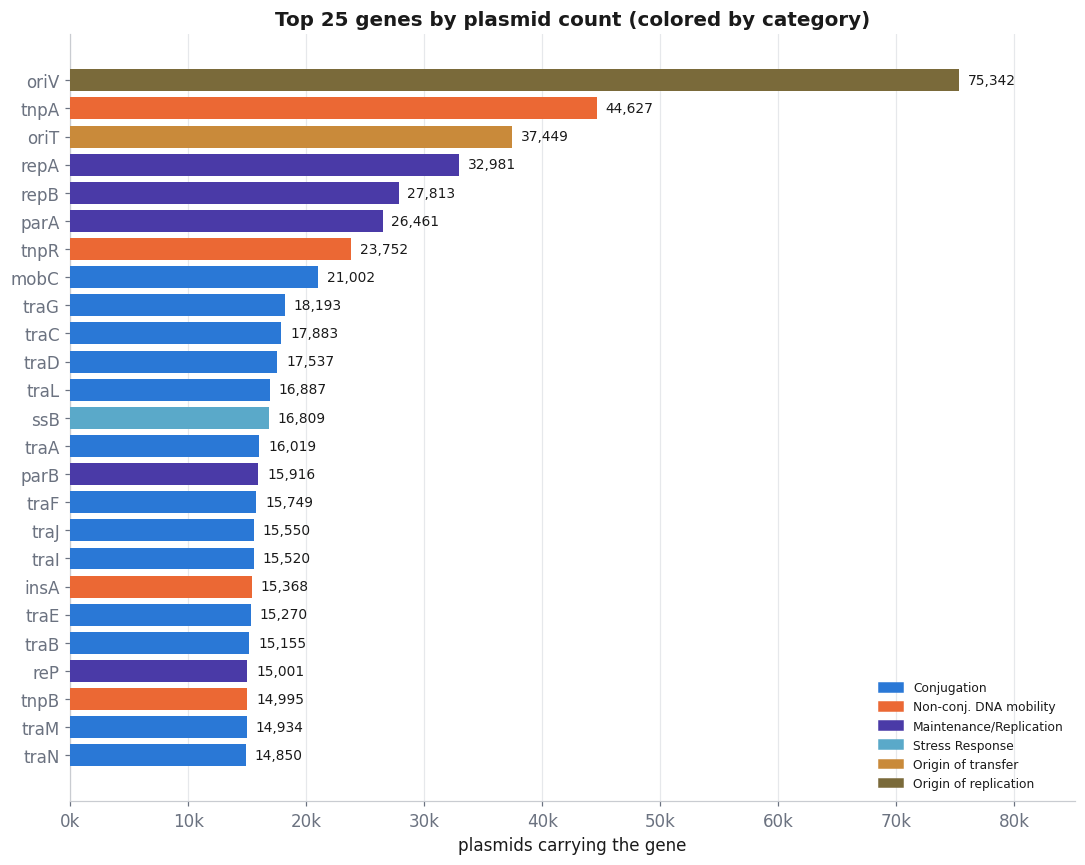

In [6]:
g = genes[genes.gene_name != "ORF"].sort_values("n_plasmids", ascending=False).head(25).sort_values("n_plasmids")
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(g.gene_name, g.n_plasmids, color=[catcol(x) for x in g.top_category], height=0.78, zorder=3)
hbar_labels(ax, g.n_plasmids.values)
ax.set_title("Top 25 genes by plasmid count (colored by category)"); ax.set_xlabel("plasmids carrying the gene")
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k")); ax.grid(axis="y", visible=False)
cats_present = list(dict.fromkeys(g.top_category))
handles = [plt.Rectangle((0, 0), 1, 1, color=catcol(x)) for x in cats_present]
ax.legend(handles, [SHORT.get(x, x) for x in cats_present], loc="lower right", fontsize=8)
fig.tight_layout(); save(fig, "03_top_genes"); plt.show()

## 4 · Replicons (PlasAnn calls)

PlasAnn's replicon families (collapsed across allelic variants). **Loose 60% BLAST threshold — an
annotation signal, not authoritative typing.** The IncF complex (IncFIB/FII/FIC/FIA), the Col family and
IncN/IncR lead, consistent with Enterobacterial plasmids.

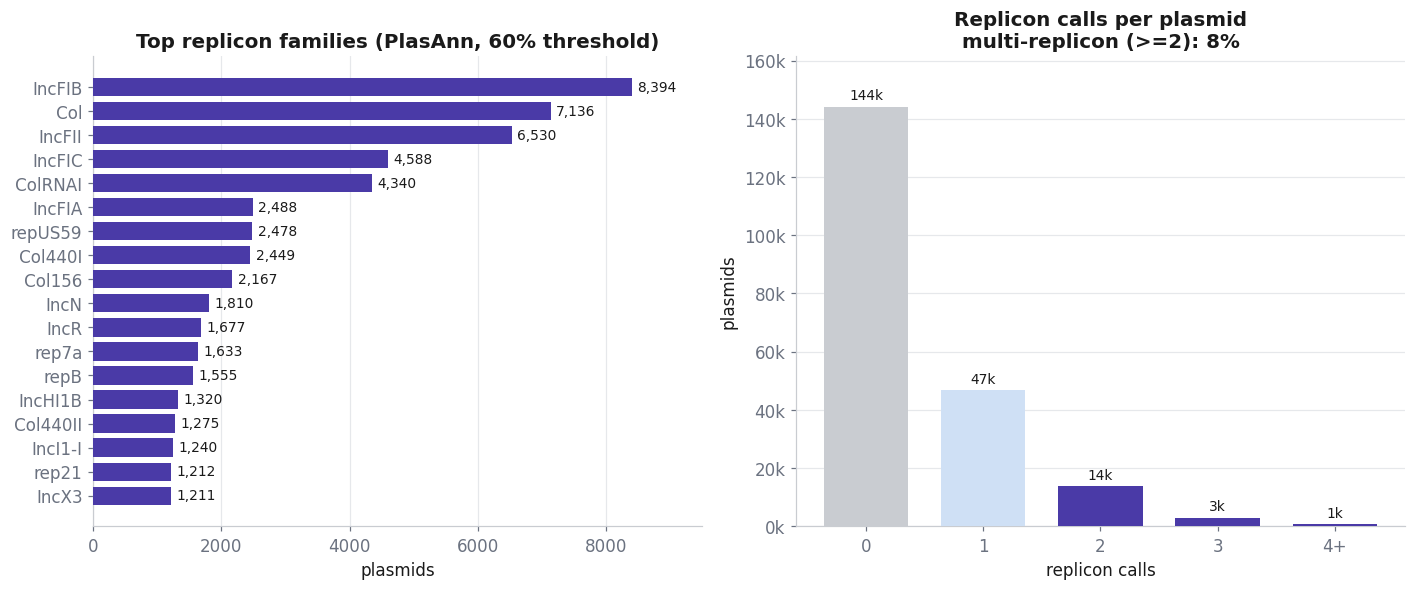

In [7]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5.5))
rf = repfam.head(18).sort_values("n_plasmids")
a1.barh(rf.family, rf.n_plasmids, color=PAL[4], height=0.76, zorder=3)
hbar_labels(a1, rf.n_plasmids.values)
a1.set_title("Top replicon families (PlasAnn, 60% threshold)"); a1.set_xlabel("plasmids"); a1.grid(axis="y", visible=False)

nr = A.plasann_n_replicons.fillna(0).astype(int).clip(upper=4)
lab = {0: "0", 1: "1", 2: "2", 3: "3", 4: "4+"}
vc = nr.value_counts().sort_index()
multi = (A.plasann_n_replicons >= 2).mean() * 100
bars = a2.bar([lab[k] for k in vc.index], vc.values,
              color=[LGREY if k == 0 else ("#cfe0f5" if k == 1 else PAL[4]) for k in vc.index], width=0.72, zorder=3)
for b, v in zip(bars, vc.values):
    a2.text(b.get_x()+b.get_width()/2, v+max(vc.values)*0.01, f"{v/1000:.0f}k", ha="center", va="bottom", fontsize=9, color=INK)
a2.set_title(f"Replicon calls per plasmid\nmulti-replicon (>=2): {multi:.0f}%"); a2.set_xlabel("replicon calls")
a2.set_ylabel("plasmids"); a2.set_ylim(0, max(vc.values)*1.12)
a2.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k")); a2.grid(axis="x", visible=False)
fig.tight_layout(); save(fig, "04_replicons"); plt.show()

## 5 · Functional content across habitats

Does gene content differ by where the plasmid was sampled? Prevalence of each functional class within
the three real habitat domains (analysis set; artifacts excluded). AMR and conjugation enrichment in
host-associated plasmids is the signal to watch.

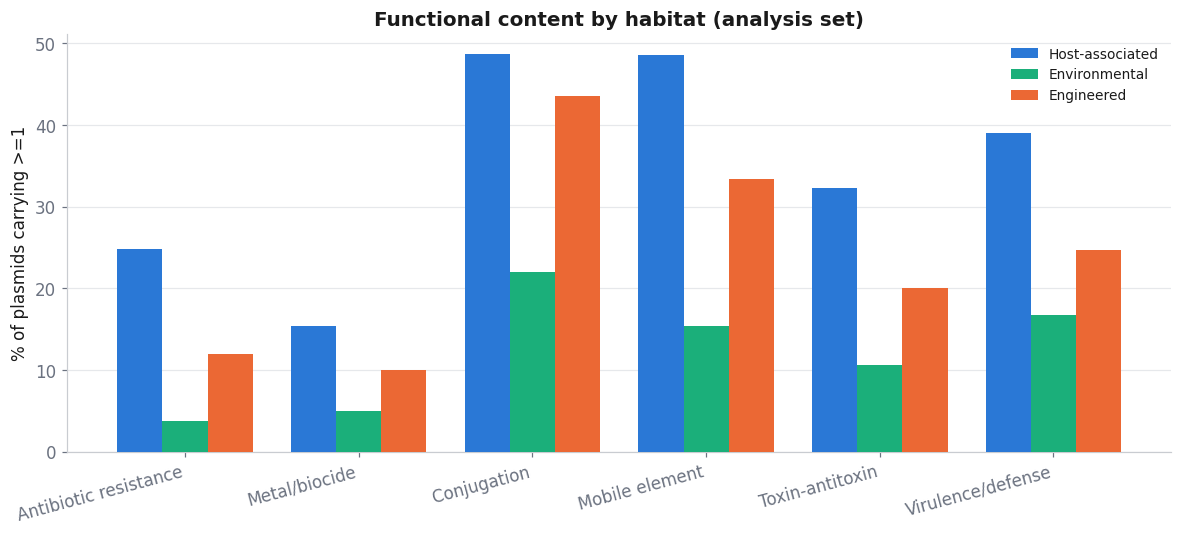

In [8]:
DOM = ["Host-associated", "Environmental", "Engineered"]
CLASSES = [("plasann_n_amr", "Antibiotic resistance"), ("plasann_n_metal_biocide", "Metal/biocide"),
           ("plasann_n_conjugation", "Conjugation"), ("plasann_n_mobile_element", "Mobile element"),
           ("plasann_n_toxin_antitoxin", "Toxin-antitoxin"), ("plasann_n_virulence", "Virulence/defense")]
prev = pd.DataFrame({lab: [ (R.loc[R.hab_top == d, col] > 0).mean()*100 for d in DOM ]
                     for col, lab in CLASSES}, index=DOM).T

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(prev)); w = 0.26
for i, d in enumerate(DOM):
    ax.bar(x + (i-1)*w, prev[d].values, w, label=d, color=HAB_COLORS[d], zorder=3)
ax.set_xticks(x); ax.set_xticklabels(prev.index, rotation=15, ha="right")
ax.set_ylabel("% of plasmids carrying >=1"); ax.set_title("Functional content by habitat (analysis set)")
ax.legend(loc="upper right", fontsize=9); ax.grid(axis="x", visible=False)
fig.tight_layout(); save(fig, "05_function_by_habitat"); plt.show()

## 6 · Gene richness & co-occurrence

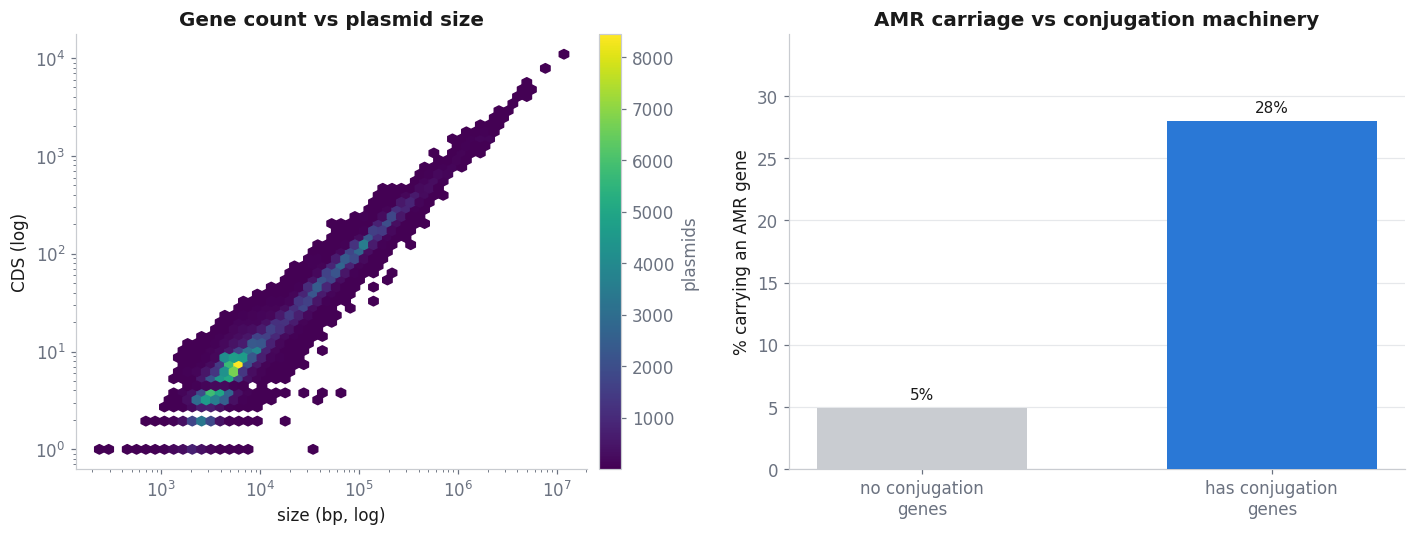

In [9]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5))

sub = A[(A.size_bp > 0) & (A.plasann_n_cds > 0)]
hb = a1.hexbin(sub.size_bp, sub.plasann_n_cds, xscale="log", yscale="log", gridsize=50,
               cmap="mako_r" if "mako_r" in plt.colormaps() else "viridis", mincnt=1)
fig.colorbar(hb, ax=a1, pad=0.02).set_label("plasmids", color=MUTED)
a1.set_title("Gene count vs plasmid size"); a1.set_xlabel("size (bp, log)"); a1.set_ylabel("CDS (log)"); a1.grid(False)

# AMR carriage vs conjugative machinery
A2 = A.copy()
A2["has_amr"] = A2.plasann_n_amr > 0
A2["conj"] = np.where(A2.plasann_n_conjugation > 0, "has conjugation genes", "no conjugation genes")
ct = A2.groupby("conj")["has_amr"].mean().reindex(["no conjugation genes", "has conjugation genes"]) * 100
bars = a2.bar(range(2), ct.values, color=[LGREY, PAL[0]], width=0.6, zorder=3)
for b, v in zip(bars, ct.values):
    a2.text(b.get_x()+b.get_width()/2, v+0.5, f"{v:.0f}%", ha="center", va="bottom", fontsize=10, color=INK)
a2.set_xticks(range(2)); a2.set_xticklabels(["no conjugation\ngenes", "has conjugation\ngenes"])
a2.set_ylabel("% carrying an AMR gene"); a2.set_title("AMR carriage vs conjugation machinery")
a2.set_ylim(0, max(ct.values)*1.25); a2.grid(axis="x", visible=False)
fig.tight_layout(); save(fig, "06_richness_cooccurrence"); plt.show()

## 7 · Summary & data dictionary

**Headline findings**

- **99.97% annotated** (208,177 / 208,248); median ~7 genes/plasmid but a heavy tail to hundreds.
- **The plasmid mobilome dominates the annotated content**: after hypothetical ORFs, the largest
  functional categories by reach are conjugation, maintenance/replication, mobile elements and
  non-conjugative DNA mobility (transposases). The top named genes are transposases (`tnpA`, `ins*`,
  `ist*`), replication/partition (`repA/B`, `parA/B`) and conjugation (`tra*`, `mob*`).
- **AMR is focal, not universal** — a minority of plasmids carry antibiotic-resistance genes, and they
  are enriched in host-associated plasmids and in plasmids that also carry conjugation machinery.
- **Replicons** (PlasAnn, loose threshold): IncF complex + Col + IncN/IncR lead; a sizeable
  multi-replicon minority — to be confirmed by the authoritative MOB-suite/PlasmidFinder typing.

**`plasann_*` columns in the master**

| column | meaning |
|---|---|
| `plasann_annotated` | 1 if PlasAnn produced an annotation |
| `plasann_n_features`, `plasann_n_cds` | total features / protein-coding genes |
| `plasann_replicons`, `plasann_n_replicons` | replicon calls (names; count) |
| `plasann_has_oriv`, `plasann_has_orit` | origin of replication / transfer present |
| `plasann_n_amr`, `plasann_n_metal_biocide` | resistance gene counts |
| `plasann_n_conjugation`, `plasann_n_mob_dna`, `plasann_n_mobile_element` | mobility machinery counts |
| `plasann_n_toxin_antitoxin`, `plasann_n_virulence`, `plasann_n_ncrna`, `plasann_n_maintenance` | other functional counts |

*Generated by `scripts/build_plasann_notebook.py`; features aggregated by
`scripts/aggregate_plasann_genes.py`; annotation by PlasAnn v1.1.6. Figures in
`reports/figures/plasann/`.*